## Caso práctico: Transformación e integración de datos de ventas

La empresa **RetailNova Perú** está modernizando su área de datos. Hoy la información de ventas se encuentra dispersa en **tres fuentes distintas**, gestionadas por equipos diferentes:

1. `ventas.csv` — transacciones diarias registradas en caja (≈ 500 registros).
2. `clientes.csv` — base de clientes del CRM (≈ 320 registros).
3. `productos.csv` — catálogo de productos del almacén (≈ 300 registros).

El problema: cada archivo fue capturado por un equipo distinto y contiene **problemas de calidad de datos** (valores nulos, registros duplicados, formatos inconsistentes). Antes de poder analizar o construir métricas, es necesario **limpiar, integrar y transformar** la información en un único dataset confiable.

### Objetivo general

Construir un **pipeline de procesamiento de datos** que permita:

1. **Cargar** las tres fuentes de datos.
2. **Limpiar** los datos (nulos, duplicados e inconsistencias).
3. **Integrar** las tablas mediante `merge` y `join`.
4. **Pivotear** la información para el análisis (`pivot`, `melt`, `stack`, `unstack`).
5. **Derivar** métricas de negocio (KPI).
6. **Exportar** el dataset final listo para análisis.

### Pipeline de procesamiento

```mermaid
flowchart LR
    A[Cargar Datos<br/>3 archivos CSV] --> B[Limpiar<br/>Nulos y duplicados]
    B --> C[Integrar<br/>merge / join]
    C --> D[Pivotear<br/>pivot / melt / stack]
    D --> E[Derivar<br/>Métricas KPI]
    E --> F[Exportar<br/>Dataset final]
```

In [61]:
# 1. Cargar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
# 2. Cargar las tres fuentes de datos
ventas = pd.read_csv("./data/ventas.csv", encoding="utf-8")
clientes = pd.read_csv("./data/clientes.csv", encoding="utf-8")
productos = pd.read_csv("./data/productos.csv", encoding="utf-8")

print("ventas   :", ventas.shape)
print("clientes :", clientes.shape)
print("productos:", productos.shape)

ventas   : (512, 8)
clientes : (320, 6)
productos: (302, 5)


In [63]:
# 3. Vista previa de cada tabla
display(ventas.head(3))
display(clientes.head(3))
display(productos.head(3))

,id_venta,fecha,id_cliente,id_producto,sucursal,cantidad,precio_unitario,metodo_pago
0,V0001,2024-01-10,C0182,P251,TRUJILLO,5.0,2521.0,EFECTIVO
1,V0002,no registrada,C0044,P116,LIMA,5.0,1217.0,TRANSFERENCIA
2,V0003,2024-01-26,C0143,P247,CUSCO,2.0,2514.0,TRANSFERENCIA


,id_cliente,nombre,ciudad,edad,segmento,fecha_registro
0,C0001,Giancarlo Castillo,AREQUIPA,55.0,VIP,2023-11-08
1,C0002,Alberto Vásquez,LIMA,111.0,NUEVO,2023-03-08
2,C0003,Alberto Castillo,AREQUIPA,84.0,REGULAR,2024-06-10


,id_producto,nombre_producto,categoria,precio_lista,costo
0,P001,PeruPC AUDIO Basic 001,AUDIO,864.0,512.07
1,P002,AndinaTech TABLET Ultra 002,TABLET,900.0,571.30
2,P003,TechNova MONITOR Pro 003,MONITOR,538.0,369.12


In [64]:
# 4. Información general de los datasets
ventas.info()
print("\n---\n")
clientes.info()
print("\n---\n")
productos.info()

<class 'pandas.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_venta         512 non-null    str    
 1   fecha            512 non-null    str    
 2   id_cliente       502 non-null    str    
 3   id_producto      504 non-null    str    
 4   sucursal         512 non-null    str    
 5   cantidad         500 non-null    float64
 6   precio_unitario  502 non-null    float64
 7   metodo_pago      501 non-null    str    
dtypes: float64(2), str(6)
memory usage: 32.1 KB

---

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_cliente      320 non-null    str    
 1   nombre          320 non-null    str    
 2   ciudad          305 non-null    str    
 3   edad            311 non-null    float64
 4   segmento        320 non-

### Observaciones iniciales

- `ventas`: columnas `id_cliente`, `id_producto`, `cantidad` y `precio_unitario` tienen valores nulos; las fechas mezclan formatos; `sucursal` y `metodo_pago` presentan variaciones de escritura.
- `clientes`: nulos en `ciudad` y `edad`; edades fuera de rango; `segmento` con distinta capitalización.
- `productos`: nulos en `categoria` y `precio_lista`; categorías con espacios y minúsculas.

In [65]:
# 5. Conteo de valores nulos por tabla
print("-- Nulos en ventas:--\n", ventas.isna().sum())
print("\n-- Nulos en clientes:--\n", clientes.isna().sum())
print("\n-- Nulos en productos:--\n", productos.isna().sum())

-- Nulos en ventas:--
 id_venta            0
fecha               0
id_cliente         10
id_producto         8
sucursal            0
cantidad           12
precio_unitario    10
metodo_pago        11
dtype: int64

-- Nulos en clientes:--
 id_cliente         0
nombre             0
ciudad            15
edad               9
segmento           0
fecha_registro     0
dtype: int64

-- Nulos en productos:--
 id_producto        0
nombre_producto    0
categoria          8
precio_lista       6
costo              0
dtype: int64


In [66]:
# 6. Limpieza de valores nulos

# 6.1 ventas: eliminar filas sin clave foránea ni medidas
ventas_limpio = ventas.dropna(
    subset=["id_cliente", "id_producto", "cantidad", "precio_unitario"]
).copy()
# completar método de pago faltante
ventas_limpio["metodo_pago"] = ventas_limpio["metodo_pago"].fillna("SIN REGISTRO")

# 6.2 clientes: completar ciudad y edad (media)
clientes_limpio = clientes.copy()
clientes_limpio["ciudad"] = clientes_limpio["ciudad"].fillna("SIN REGISTRO")
clientes_limpio["edad"] = clientes_limpio["edad"].fillna(clientes_limpio["edad"].median())

# 6.3 productos: completar categoría y precio de lista
productos_limpio = productos.copy()
productos_limpio["categoria"] = productos_limpio["categoria"].fillna("SIN CATEGORIA")
productos_limpio["precio_lista"] = productos_limpio["precio_lista"].fillna(
    productos_limpio["precio_lista"].median()
)

In [67]:
# 7. Análisis y eliminación de registros duplicados
print("Duplicados en ventas   :", ventas_limpio.duplicated().sum())
print("Duplicados en clientes :", clientes_limpio.duplicated(subset=["id_cliente"]).sum())
print("Duplicados en productos:", productos_limpio.duplicated(subset=["id_producto"]).sum())

ventas_limpio = ventas_limpio.drop_duplicates()
clientes_limpio = clientes_limpio.drop_duplicates(subset=["id_cliente"])
productos_limpio = productos_limpio.drop_duplicates(subset=["id_producto"])

Duplicados en ventas   : 12
Duplicados en clientes : 0
Duplicados en productos: 2


In [68]:
# 8. Consistencia: normalizar textos (mayúsculas y sin espacios)
ventas_limpio["sucursal"] = ventas_limpio["sucursal"].str.upper().str.strip()
ventas_limpio["metodo_pago"] = ventas_limpio["metodo_pago"].str.upper().str.strip()

clientes_limpio["ciudad"] = clientes_limpio["ciudad"].str.upper().str.strip()
clientes_limpio["segmento"] = clientes_limpio["segmento"].str.upper().str.strip()

productos_limpio["categoria"] = productos_limpio["categoria"].str.upper().str.strip()

In [69]:
# 9. Consistencia: normalizar fechas (formatos mixtos) a datetime
ventas_limpio["fecha"] = pd.to_datetime(
    ventas_limpio["fecha"], errors="coerce", format="mixed"
)
print("Fechas inválidas (NaT):", ventas_limpio["fecha"].isna().sum())
ventas_limpio = ventas_limpio.dropna(subset=["fecha"])

Fechas inválidas (NaT): 3


In [70]:
# 10. Consistencia: filtrar valores fuera de rango
# Cantidades negativas o excesivas en ventas
ventas_limpio = ventas_limpio[
    (ventas_limpio["cantidad"] > 0) & (ventas_limpio["cantidad"] <= 50)
]

# Edades irreales en clientes
clientes_limpio = clientes_limpio[
    (clientes_limpio["edad"] > 0) & (clientes_limpio["edad"] <= 100)
]

# Precios no positivos en productos
productos_limpio = productos_limpio[productos_limpio["precio_lista"] > 0]

In [71]:
# 11. Consistencia referencial: conservar solo claves que existen en las dimensiones
ventas_limpio = ventas_limpio[ventas_limpio["id_cliente"].isin(clientes_limpio["id_cliente"])]
ventas_limpio = ventas_limpio[ventas_limpio["id_producto"].isin(productos_limpio["id_producto"])]

print("Registros finales en ventas:", ventas_limpio.shape[0])

Registros finales en ventas: 439


In [72]:
# 12. Verificación final de la limpieza
print("Nulos restantes en ventas:\n", ventas_limpio.isna().sum())
print("\nDuplicados restantes:", ventas_limpio.duplicated().sum())

Nulos restantes en ventas:
 id_venta           0
fecha              0
id_cliente         0
id_producto        0
sucursal           0
cantidad           0
precio_unitario    0
metodo_pago        0
dtype: int64

Duplicados restantes: 0


### Integración de datos

Con las tres tablas limpias, las integramos en un único dataframe analítico:

- **`merge`**: combina columnas de dos tablas a partir de una o varias claves comunes.
- **`join`**: une dos tablas usando sus índices (o el índice de una y una columna de la otra).

In [73]:
# 13. Integrar con merge: ventas + productos (inner join por id_producto)
df = ventas_limpio.merge(productos_limpio, on="id_producto", how="inner")

# merge: agregar datos del cliente (inner join por id_cliente)
df = df.merge(clientes_limpio, on="id_cliente", how="inner")

print("Dataset integrado:", df.shape)
df.head()

Dataset integrado: (439, 17)


,id_venta,fecha,id_cliente,id_producto,sucursal,cantidad,precio_unitario,metodo_pago,nombre_producto,categoria,precio_lista,costo,nombre,ciudad,edad,segmento,fecha_registro
0,V0001,2024-01-10,C0182,P251,TRUJILLO,5.0,2521.0,EFECTIVO,PeruPC LAPTOP Pro 251,LAPTOP,3550.0,2492.72,Gabriela Castillo,AREQUIPA,64.0,REGULAR,2024-03-18
1,V0003,2024-01-26,C0143,P247,CUSCO,2.0,2514.0,TRANSFERENCIA,PeruPC ACCESORIO Plus 247,ACCESORIO,126.0,77.73,Óscar Díaz,CUSCO,55.0,VIP,2023-04-12
2,V0004,2024-05-26,C0302,P094,CUSCO,8.0,1742.0,TARJETA,MaxDigital LAPTOP Pro 094,LAPTOP,1870.0,1143.16,Cliente 9694,TRUJILLO,56.0,VIP,2023-04-23
3,V0005,2024-02-27,C0244,P265,TRUJILLO,9.0,1652.0,EFECTIVO,AndinaTech TABLET Basic 265,TABLET,1199.0,682.91,César Torres,CHICLAYO,37.0,VIP,2024-07-24
4,V0006,2024-04-13,C0082,P098,TRUJILLO,9.0,1420.0,TARJETA,TechNova ACCESORIO Neo 098,ACCESORIO,92.0,57.95,Alejandra Aguilar,CUSCO,27.0,VIP,2024-02-24


In [75]:
# 14. Alternativa con join (usa el índice de la tabla derecha)
# Convertimos id_cliente en el índice de clientes y unimos por la izquierda
df_join = ventas_limpio.join(
    clientes_limpio.set_index("id_cliente"), on="id_cliente", how="left"
)
print("Resultado del join (izquierda):", df_join.shape)
df_join.head()

Resultado del join (izquierda): (439, 13)


,id_venta,fecha,id_cliente,id_producto,sucursal,cantidad,precio_unitario,metodo_pago,nombre,ciudad,edad,segmento,fecha_registro
0,V0001,2024-01-10,C0182,P251,TRUJILLO,5.0,2521.0,EFECTIVO,Gabriela Castillo,AREQUIPA,64.0,REGULAR,2024-03-18
2,V0003,2024-01-26,C0143,P247,CUSCO,2.0,2514.0,TRANSFERENCIA,Óscar Díaz,CUSCO,55.0,VIP,2023-04-12
3,V0004,2024-05-26,C0302,P094,CUSCO,8.0,1742.0,TARJETA,Cliente 9694,TRUJILLO,56.0,VIP,2023-04-23
4,V0005,2024-02-27,C0244,P265,TRUJILLO,9.0,1652.0,EFECTIVO,César Torres,CHICLAYO,37.0,VIP,2024-07-24
5,V0006,2024-04-13,C0082,P098,TRUJILLO,9.0,1420.0,TARJETA,Alejandra Aguilar,CUSCO,27.0,VIP,2024-02-24


In [76]:
# Agregamos el cruce con productos usando join
df_join = df_join.join(
    productos_limpio.set_index("id_producto"), on="id_producto", how="left"
)
df_join.head()

,id_venta,fecha,id_cliente,id_producto,sucursal,cantidad,precio_unitario,metodo_pago,nombre,ciudad,edad,segmento,fecha_registro,nombre_producto,categoria,precio_lista,costo
0,V0001,2024-01-10,C0182,P251,TRUJILLO,5.0,2521.0,EFECTIVO,Gabriela Castillo,AREQUIPA,64.0,REGULAR,2024-03-18,PeruPC LAPTOP Pro 251,LAPTOP,3550.0,2492.72
2,V0003,2024-01-26,C0143,P247,CUSCO,2.0,2514.0,TRANSFERENCIA,Óscar Díaz,CUSCO,55.0,VIP,2023-04-12,PeruPC ACCESORIO Plus 247,ACCESORIO,126.0,77.73
3,V0004,2024-05-26,C0302,P094,CUSCO,8.0,1742.0,TARJETA,Cliente 9694,TRUJILLO,56.0,VIP,2023-04-23,MaxDigital LAPTOP Pro 094,LAPTOP,1870.0,1143.16
4,V0005,2024-02-27,C0244,P265,TRUJILLO,9.0,1652.0,EFECTIVO,César Torres,CHICLAYO,37.0,VIP,2024-07-24,AndinaTech TABLET Basic 265,TABLET,1199.0,682.91
5,V0006,2024-04-13,C0082,P098,TRUJILLO,9.0,1420.0,TARJETA,Alejandra Aguilar,CUSCO,27.0,VIP,2024-02-24,TechNova ACCESORIO Neo 098,ACCESORIO,92.0,57.95


In [77]:
# 15. Crear la medida clave para el análisis: importe de la venta (nuevas columnas)
df["importe"] = df["cantidad"] * df["precio_unitario"]
df["mes"] = df["fecha"].dt.to_period("M")
df.head()

,id_venta,fecha,id_cliente,id_producto,sucursal,cantidad,precio_unitario,metodo_pago,nombre_producto,categoria,precio_lista,costo,nombre,ciudad,edad,segmento,fecha_registro,importe,mes
0,V0001,2024-01-10,C0182,P251,TRUJILLO,5.0,2521.0,EFECTIVO,PeruPC LAPTOP Pro 251,LAPTOP,3550.0,2492.72,Gabriela Castillo,AREQUIPA,64.0,REGULAR,2024-03-18,12605.0,2024-01
1,V0003,2024-01-26,C0143,P247,CUSCO,2.0,2514.0,TRANSFERENCIA,PeruPC ACCESORIO Plus 247,ACCESORIO,126.0,77.73,Óscar Díaz,CUSCO,55.0,VIP,2023-04-12,5028.0,2024-01
2,V0004,2024-05-26,C0302,P094,CUSCO,8.0,1742.0,TARJETA,MaxDigital LAPTOP Pro 094,LAPTOP,1870.0,1143.16,Cliente 9694,TRUJILLO,56.0,VIP,2023-04-23,13936.0,2024-05
3,V0005,2024-02-27,C0244,P265,TRUJILLO,9.0,1652.0,EFECTIVO,AndinaTech TABLET Basic 265,TABLET,1199.0,682.91,César Torres,CHICLAYO,37.0,VIP,2024-07-24,14868.0,2024-02
4,V0006,2024-04-13,C0082,P098,TRUJILLO,9.0,1420.0,TARJETA,TechNova ACCESORIO Neo 098,ACCESORIO,92.0,57.95,Alejandra Aguilar,CUSCO,27.0,VIP,2024-02-24,12780.0,2024-04


### Pivoteo de tablas

Transformamos la tabla larga (una fila por venta) en tablas resumen para el análisis:

- **`pivot_table` / `pivot`**: tabla larga → tabla ancha (resumen por filas y columnas).
- **`melt`**: tabla ancha → tabla larga (unpivot).
- **`stack` / `unstack`**: mover niveles entre filas y columnas en un `MultiIndex`.

In [78]:
# 16. Pivot table: importe total por sucursal (filas) y categoría (columnas)
pivot_ingresos = df.pivot_table(
    index="sucursal", columns="categoria",
    values="importe", aggfunc="sum", fill_value=0
)
pivot_ingresos.round(2)

categoria,ACCESORIO,AUDIO,CELULAR,LAPTOP,MONITOR,SIN CATEGORIA,TABLET
sucursal,,,,,,,
AREQUIPA,108001.0,206074.0,215105.0,78755.0,109600.0,13112.0,234220.0
CUSCO,121998.0,244478.0,152408.0,219308.0,191674.0,8460.0,144443.0
LIMA,126752.0,122977.0,101121.0,138182.0,69565.0,23940.0,113164.0
TRUJILLO,207422.0,195736.0,106512.0,164453.0,96909.0,90044.0,199877.0


In [80]:
# 17. Pivot (requiere claves únicas): agrupamos primero para asegurar unicidad
base = df.groupby(["sucursal", "categoria"], as_index=False)["importe"].sum()
pivot_estricto = base.pivot(
    index="sucursal", columns="categoria", values="importe"
).fillna(0)
pivot_estricto.round(2)

categoria,ACCESORIO,AUDIO,CELULAR,LAPTOP,MONITOR,SIN CATEGORIA,TABLET
sucursal,,,,,,,
AREQUIPA,108001.0,206074.0,215105.0,78755.0,109600.0,13112.0,234220.0
CUSCO,121998.0,244478.0,152408.0,219308.0,191674.0,8460.0,144443.0
LIMA,126752.0,122977.0,101121.0,138182.0,69565.0,23940.0,113164.0
TRUJILLO,207422.0,195736.0,106512.0,164453.0,96909.0,90044.0,199877.0


In [81]:
# 18. Melt (unpivot): devolver la tabla ancha a formato largo
tabla_larga = pivot_ingresos.reset_index().melt(
    id_vars="sucursal", var_name="categoria", value_name="importe"
)
tabla_larga.head(10)

,sucursal,categoria,importe
0,AREQUIPA,ACCESORIO,108001.0
1,CUSCO,ACCESORIO,121998.0
2,LIMA,ACCESORIO,126752.0
3,TRUJILLO,ACCESORIO,207422.0
4,AREQUIPA,AUDIO,206074.0
5,CUSCO,AUDIO,244478.0
6,LIMA,AUDIO,122977.0
7,TRUJILLO,AUDIO,195736.0
8,AREQUIPA,CELULAR,215105.0
9,CUSCO,CELULAR,152408.0


In [82]:
# 19. Stack: convertir columnas (categorías) en filas -> Series con MultiIndex
apilado = pivot_estricto.stack()
print("Resultado de stack (MultiIndex):")
apilado.head(10)

Resultado de stack (MultiIndex):


sucursal  categoria    
AREQUIPA  ACCESORIO        108001.0
          AUDIO            206074.0
          CELULAR          215105.0
          LAPTOP            78755.0
          MONITOR          109600.0
          SIN CATEGORIA     13112.0
          TABLET           234220.0
CUSCO     ACCESORIO        121998.0
          AUDIO            244478.0
          CELULAR          152408.0
dtype: float64

In [83]:
# 20. Unstack: devolver el MultiIndex a formato ancho
desapilado = apilado.unstack(fill_value=0)
desapilado.round(2)

categoria,ACCESORIO,AUDIO,CELULAR,LAPTOP,MONITOR,SIN CATEGORIA,TABLET
sucursal,,,,,,,
AREQUIPA,108001.0,206074.0,215105.0,78755.0,109600.0,13112.0,234220.0
CUSCO,121998.0,244478.0,152408.0,219308.0,191674.0,8460.0,144443.0
LIMA,126752.0,122977.0,101121.0,138182.0,69565.0,23940.0,113164.0
TRUJILLO,207422.0,195736.0,106512.0,164453.0,96909.0,90044.0,199877.0


In [85]:
# 21. Melt sobre ventas mensuales por sucursal (ancho -> largo)
ventas_mensuales = df.pivot_table(
    index="mes", columns="sucursal",
    values="importe", aggfunc="sum", fill_value=0
)
ventas_mensuales

sucursal,AREQUIPA,CUSCO,LIMA,TRUJILLO
mes,,,,
2024-01,254933.0,126087.0,121761.0,239360.0
2024-02,244265.0,153895.0,111448.0,214176.0
2024-03,91749.0,280384.0,99730.0,198638.0
2024-04,160439.0,170617.0,45368.0,109901.0
2024-05,144055.0,186814.0,249927.0,122395.0
2024-06,69426.0,164972.0,67467.0,176483.0


In [86]:
ventas_mensuales_long = ventas_mensuales.reset_index().melt(
    id_vars="mes", var_name="sucursal", value_name="importe"
)
ventas_mensuales_long.head()

,mes,sucursal,importe
0,2024-01,AREQUIPA,254933.0
1,2024-02,AREQUIPA,244265.0
2,2024-03,AREQUIPA,91749.0
3,2024-04,AREQUIPA,160439.0
4,2024-05,AREQUIPA,144055.0


### Métricas derivadas (KPI)

Con el dataset integrado y limpio calculamos los indicadores que la gerencia necesita para tomar decisiones.

In [88]:
# 22. Calcular métricas de negocio
total_ingresos = df["importe"].sum()
ticket_promedio = df["importe"].mean()
num_transacciones = df["id_venta"].nunique()
clientes_unicos = df["id_cliente"].nunique()
productos_vendidos = df["id_producto"].nunique()

# Mostrar indicadores
print(f"Ingresos totales: {total_ingresos:,.2f}")
print(f"Ticket promedio: {ticket_promedio:,.2f}")
print(f"N° transacciones: {num_transacciones}")
print(f"Clientes únicos: {clientes_unicos}")
print(f"Productos vendidos: {productos_vendidos}")

Ingresos totales: 3,804,290.00
Ticket promedio: 8,665.81
N° transacciones: 439
Clientes únicos: 242
Productos vendidos: 231


In [89]:
# Mostrar en formato dataframe
kpis = pd.DataFrame({
    "Métrica": ["Ingresos totales", "Ticket promedio", "N° transacciones",
                "Clientes únicos", "Productos vendidos"],
    "Valor": [f"{total_ingresos:,.2f}", f"{ticket_promedio:,.2f}",
              num_transacciones, clientes_unicos, productos_vendidos]
})
kpis

,Métrica,Valor
0,Ingresos totales,"3,804,290.00"
1,Ticket promedio,"8,665.81"
2,N° transacciones,439
3,Clientes únicos,242
4,Productos vendidos,231


<Axes: title={'center': 'Top 5 productos por ingresos'}, xlabel='Producto', ylabel='Ingresos'>

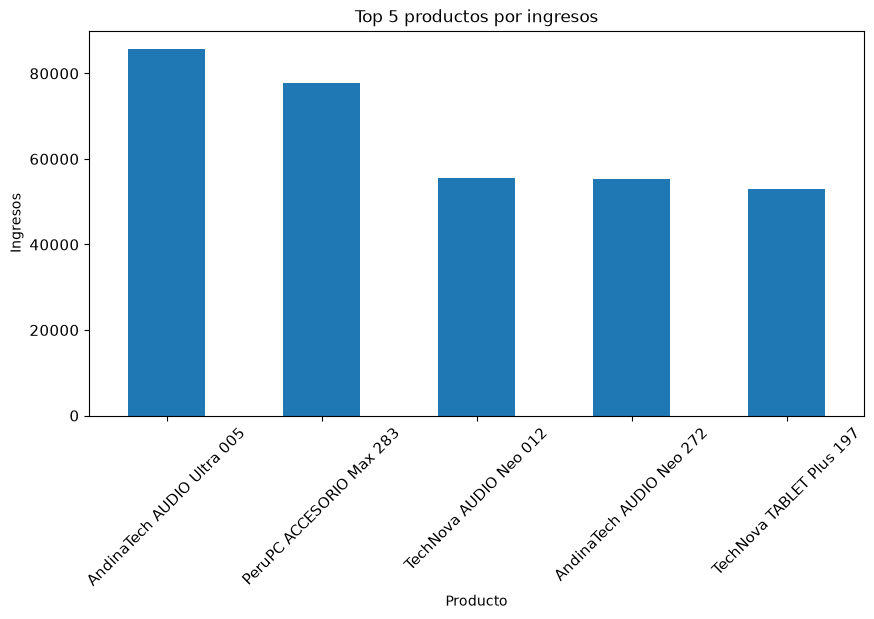

In [92]:
# 23. Top 5 productos por ingresos
top_productos = df.groupby("nombre_producto")["importe"].sum().nlargest(5)
top_productos.plot.bar(
    figsize=(10, 5), title="Top 5 productos por ingresos",
    xlabel="Producto", ylabel="Ingresos", rot=45, legend=False, fontsize=11
)

In [93]:
# 24. Exportar el dataset final y la tabla pivoteada
df.to_csv("./exports/dataset_ventas_final.csv", index=False, encoding="utf-8")
pivot_ingresos.to_csv("./exports/pivot_ingresos_sucursal_categoria.csv", encoding="utf-8")

print("Dataset final exportado a ./exports/dataset_ventas_final.csv")

Dataset final exportado a ./exports/dataset_ventas_final.csv


### Conclusiones

- La **limpieza** eliminó nulos, duplicados y valores fuera de rango, dejando un dataset íntegro.
- La **normalización de textos** evitó que valores como `"LIMA"` y `" lima"` se contaran como categorías distintas.
- Con **`merge`** integramos las tres fuentes en un único dataframe analítico; con **`join`** vimos una alternativa basada en índices.
- Con **`pivot_table`/`pivot`** resumimos ingresos por sucursal y categoría; con **`melt`** y **`stack`/`unstack`** revertimos el proceso entre formato ancho y largo.
- Las **métricas** permiten a la gerencia medir ingresos, ticket promedio y desempeño por producto.